<a href="https://colab.research.google.com/github/RafaMota26/Inform-tica/blob/main/vinho_vermelho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumit17125/red-wine-quality-dataset")

print("Path to dataset files:", path)


100%|██████████| 24.0k/24.0k [00:00<00:00, 30.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sumit17125/red-wine-quality-dataset/versions/1


In [2]:
import os
import pandas as pd

In [4]:
# List files in the downloaded dataset path
file_list = os.listdir(path)
print("Files in dataset directory:", file_list)

# Assuming the CSV file is named 'WineQT.csv' or similar based on typical Kaggle datasets
csv_file = [f for f in file_list if f.endswith('.csv')][0]
csv_file_path = os.path.join(path, csv_file)

# Load the CSV file into a pandas DataFrame, specifying semicolon as separator
df = pd.read_csv(csv_file_path, sep=';')

# Display the first 5 rows of the DataFrame
display(df.head())

Files in dataset directory: ['winequality-red.csv']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Data Preprocessing for Linear Regression

Before building the model, let's inspect the dataset for any missing values and define our features (X) and target (y).

In [5]:
print("DataFrame Info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
resi

### Define Features (X) and Target (y)

We will use all columns except 'quality' as features and 'quality' as our target variable.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop('quality', axis=1)
y = df['quality']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (1599, 11)
Shape of target (y): (1599,)


### Split Data into Training and Testing Sets

We will split the data into 80% for training and 20% for testing to evaluate the model's performance on unseen data.

In [7]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1279, 11)
X_test shape: (320, 11)
y_train shape: (1279,)
y_test shape: (320,)


### Train the Linear Regression Model

Now, let's create and train a Linear Regression model.

In [8]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Evaluate the Model

We will evaluate the model's performance on the test set using various metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared.

In [9]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R-squared (R2): {r2:.3f}")

Mean Absolute Error (MAE): 0.504
Mean Squared Error (MSE): 0.390
Root Mean Squared Error (RMSE): 0.625
R-squared (R2): 0.403


### Visualize Model Predictions

Let's visualize the actual vs. predicted values to get a better understanding of the model's performance.

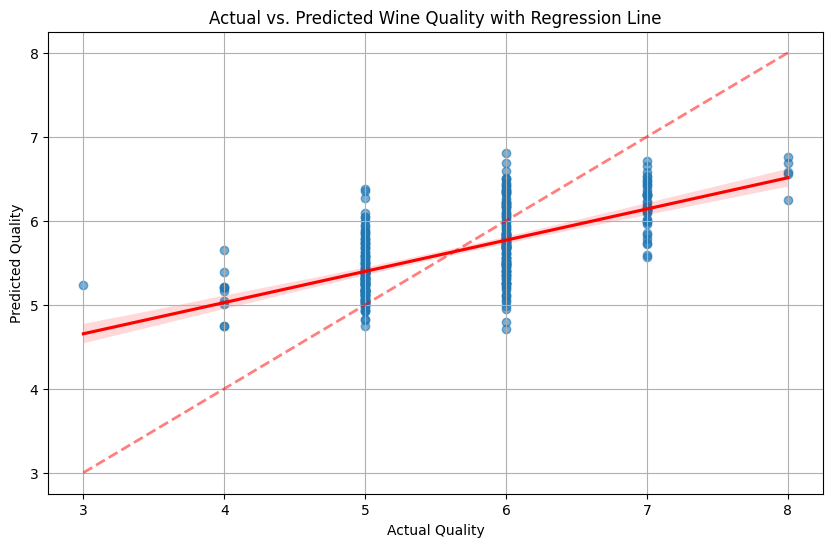

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, alpha=0.5) # Diagonal line for perfect prediction
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs. Predicted Wine Quality with Regression Line")
plt.grid(True)
plt.show()